<a href="https://colab.research.google.com/github/barakavic/cvd-data-mining-capstone/blob/main/CVD_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
df = pd.read_csv('cardio_train.csv', sep=';')
print ("Shape", df.shape)
print (df.head())

Shape (70000, 13)
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [4]:
print (df.dtypes)


id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


In [5]:
print (df.isnull().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [6]:
print(df.describe())

                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571    164.359229     74.205690   
std    28851.302323   2467.251667      0.476838      8.210126     14.395757   
min        0.000000  10798.000000      1.000000     55.000000     10.000000   
25%    25006.750000  17664.000000      1.000000    159.000000     65.000000   
50%    50001.500000  19703.000000      1.000000    165.000000     72.000000   
75%    74889.250000  21327.000000      2.000000    170.000000     82.000000   
max    99999.000000  23713.000000      2.000000    250.000000    200.000000   

              ap_hi         ap_lo   cholesterol          gluc         smoke  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean     128.817286     96.630414      1.366871      1.226457      0.088129   
std      154.011419    188.472530      0.680250    

Checks how many patients have CVD vs how many dont

In [7]:
print(df['cardio'].value_counts())
print (df['cardio'].value_counts(normalize=True) * 100)

cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


Detecting outliers

In [8]:
# Extreme blood pressure outliers
print("suspicious ap_hi values:")
print(df[df['ap_hi'] >250]['ap_hi'].value_counts().head(10))

print("\nSuspicious ap_lo values")
print(df[df['ap_lo'] > 150]['ap_lo'].value_counts().head(10))

suspicious ap_hi values:
ap_hi
906      6
14020    4
907      3
1400     3
1420     2
1300     2
13010    2
11500    1
902      1
701      1
Name: count, dtype: int64

Suspicious ap_lo values
ap_lo
1000    666
1100    156
1200     21
1110     11
160       9
1001      8
170       6
800       5
1120      5
1008      4
Name: count, dtype: int64


There were clear data entry errors with BP reaching 14,000 while normal BP is 120/180 in ap_hi while ap_lo has 666 rows with 1000 which would greatly skew the data

In [9]:
print("Rows before cleaning:", len(df))

Rows before cleaning: 70000


The original dataset is 70000 rows big

Normal human systolic BP: 60-250
Normal human diastolic BP: 40-150
Diastolic should be lower than systolic

In [10]:
df = df[df['ap_hi'] >= 60]
df = df[df['ap_hi'] <=250 ]
df = df[df['ap_lo'] >=40]
df = df[df['ap_lo'] <= 150]
df = df[df['ap_hi'] > df['ap_lo']]

print("Rows after BP cleaning:", len(df))

Rows after BP cleaning: 68667


No adult human being's height is lower than 100cm and a few subset of humans are taller than 243 cm. No adult weighs less than 30kg and the cap is at 200kg

In [11]:
df = df[df['height'] >= 100]
df = df[df['height'] <= 243]
df = df[df['weight'] >= 30]
df = df[df['weight'] <= 200]

print ("Rows after weight and height cleaning:", len(df))

Rows after weight and height cleaning: 68634


Age is stored in days

In [12]:
df ['age'] = (df['age']/ 365.25).round(1)
print("Age range after conversion:")
print(f"Youngest: {df['age'].min()} years")
print(f"Oldest: {df['age'].max()} years")
print(f"Average: {df['age'].mean():.1f} years")

Age range after conversion:
Youngest: 29.6 years
Oldest: 64.9 years
Average: 53.3 years


Calculate BMI

In [13]:
df['bmi'] = (df['weight']/ ((df['height'] /100 ) ** 2)). round(1)
print("BMI stats: ")
print(df['bmi'].describe())

BMI stats: 
count    68634.000000
mean        27.471925
std          5.352619
min         10.700000
25%         23.900000
50%         26.300000
75%         30.100000
max        152.600000
Name: bmi, dtype: float64


Normal BMI ranges from 18.5 to 24.9 with the lowest BMI being ~6.7-7.5 and highest recorded BMI ~186. A BMI below 15 causes servere health complications while a BMI above 40 is considered morbidly obese.
For anomaly monitoring in this study, BMI values below 10 and above 60 are treated as anomalies, as these values represent extreme physiological conditions or potential data irregularities.

In [14]:
df = df[df['bmi'] <= 60]
df = df[df['bmi'] >= 10]

print("Rows after cleaning: ", len(df))
print("\nBMI stats after cleaning: ")
print(df['bmi'].describe())

Rows after cleaning:  68600

BMI stats after cleaning: 
count    68600.000000
mean        27.447708
std          5.214203
min         10.700000
25%         23.900000
50%         26.300000
75%         30.100000
max         60.000000
Name: bmi, dtype: float64


After cleaning 1400 rows of data were removed

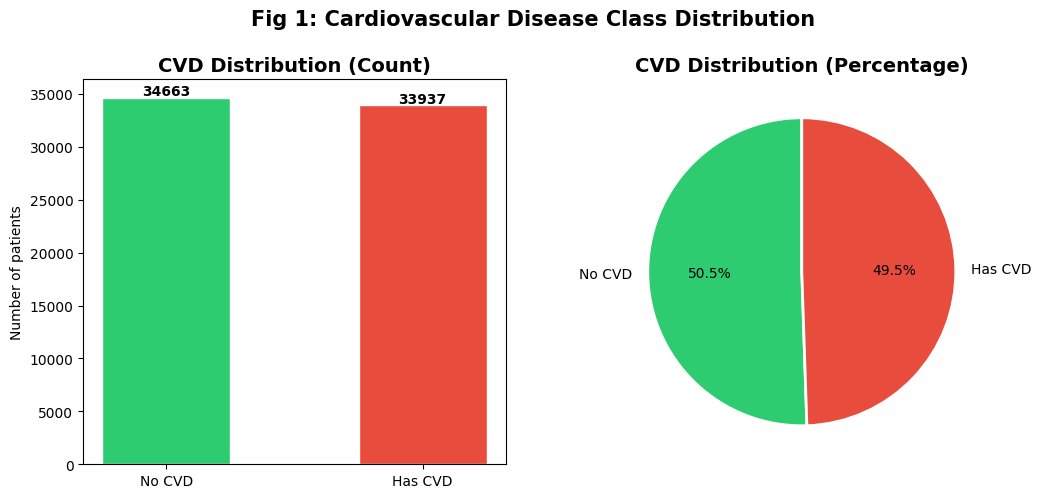

Chart 1 saved!


In [15]:
import matplotlib.pyplot as plt

labels = ['No CVD', 'Has CVD']
counts = df['cardio'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1,2, figsize=(12,5))

#Bar chart
axes[0].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('CVD Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of patients')
for i, v in enumerate(counts):
  axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

#Pie Chart
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('CVD Distribution (Percentage)', fontsize=14, fontweight='bold')


plt.suptitle('Fig 1: Cardiovascular Disease Class Distribution',
             fontsize=15, fontweight='bold', y=1.02)
plt.savefig('chart1_cvd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

The dataset is perfectly balanced with a 50.5% and 49.5% dplit

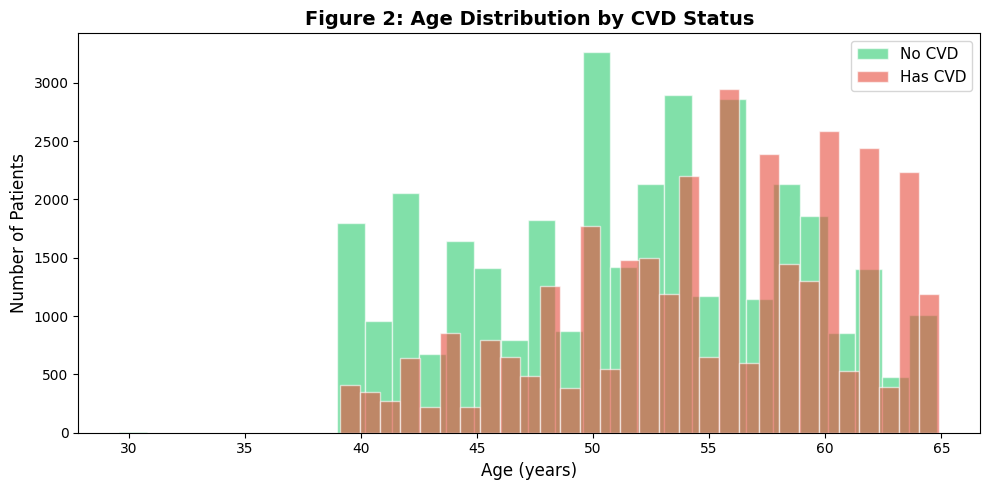

Chart 2 saved!


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histogram for each group separately
ax.hist(df[df['cardio'] == 0]['age'], bins=30, alpha=0.6,
        color='#2ecc71', label='No CVD', edgecolor='white')
ax.hist(df[df['cardio'] == 1]['age'], bins=30, alpha=0.6,
        color='#e74c3c', label='Has CVD', edgecolor='white')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Figure 2: Age Distribution by CVD Status',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart2_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

Histogram analysis revealed that CVD incidence peaks a t the age of 55 while patients aged 50 and below show a higher propotion of CVD-free cases suggesting a critical prevention window in late 40's to early 50s

/tmp/ipykernel_319/3423140160.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_cvd['bmi'], has_cvd['bmi']],


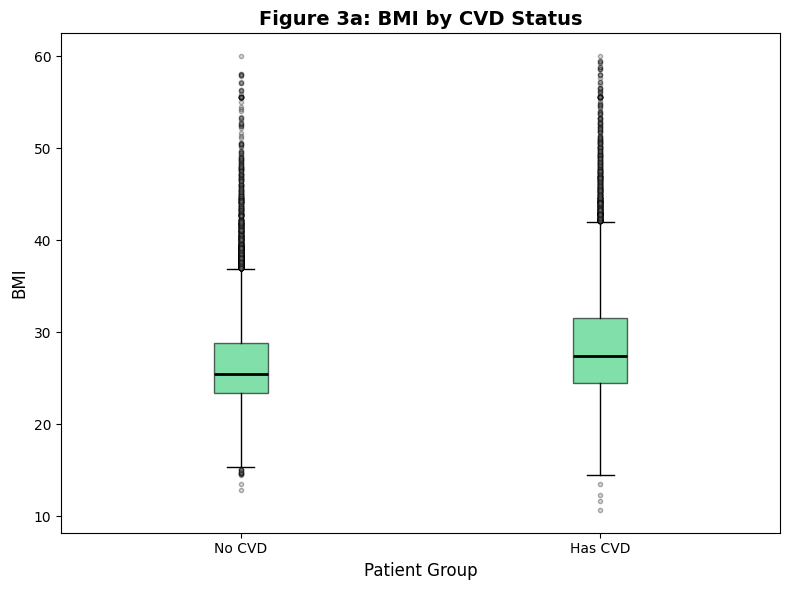

Chart 3a saved!


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

no_cvd = df[df['cardio'] == 0]
has_cvd = df[df['cardio'] == 1]

ax.boxplot([no_cvd['bmi'], has_cvd['bmi']],
           labels=['No CVD', 'Has CVD'],
           patch_artist=True,
           boxprops=dict(facecolor='#2ecc71', alpha=0.6),
           medianprops=dict(color='black', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.3))

ax.set_title('Figure 3a: BMI by CVD Status', fontsize=14, fontweight='bold')
ax.set_ylabel('BMI', fontsize=12)
ax.set_xlabel('Patient Group', fontsize=12)

plt.tight_layout()
plt.savefig('chart3a_bmi_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3a saved!")

The above box plot compares the median BMI between correspondents with  CVD and those without. Those with no CVD have a median BMI of ~25 while those with CVD have a median BMi of about ~27-28: Patients with CVD tend to have a higher BMI on average.

The whiskers show that patients with CVD have a higher BMI spread especially towards ahigher BMI

The outliers indicate that extreme BMI values occur in both groups but a high BMI is more prevalent in the group that has CVD

/tmp/ipykernel_319/4132599226.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_cvd['ap_hi'], has_cvd['ap_hi']],


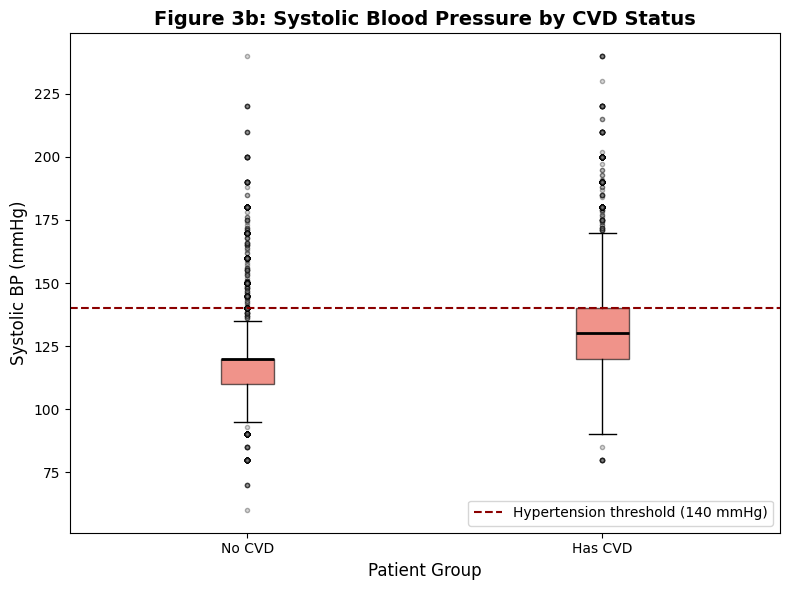

Chart 3b saved!


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot([no_cvd['ap_hi'], has_cvd['ap_hi']],
           labels=['No CVD', 'Has CVD'],
           patch_artist=True,
           boxprops=dict(facecolor='#e74c3c', alpha=0.6),
           medianprops=dict(color='black', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='gray',
                          markersize=3, alpha=0.3))

ax.set_title('Figure 3b: Systolic Blood Pressure by CVD Status',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Systolic BP (mmHg)', fontsize=12)
ax.set_xlabel('Patient Group', fontsize=12)

# The 140mmHg is teh critical threshhold for hypertension
ax.axhline(y=140, color='darkred', linestyle='--',
           linewidth=1.5, label='Hypertension threshold (140 mmHg)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart3b_systolic_bp_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3b saved!")

Patients with CVD tend to have a higher systolic blood pressure since no CVD median is < 125 and has CVD median is >125  

The IQR ranges from 100< x < 125 for no CVD while for has CVD it ranges from 115 < x < 125 meaning theres an upwards distribution meaning higher blood pressure is common for cardiovascular diseases

The has CVD group sits right at the hypertension threshhold of 140mmHg reinforcing hypertension is a key factor in cadiovasular diseases

/tmp/ipykernel_319/1935751561.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_cvd['ap_lo'], has_cvd['ap_lo']],


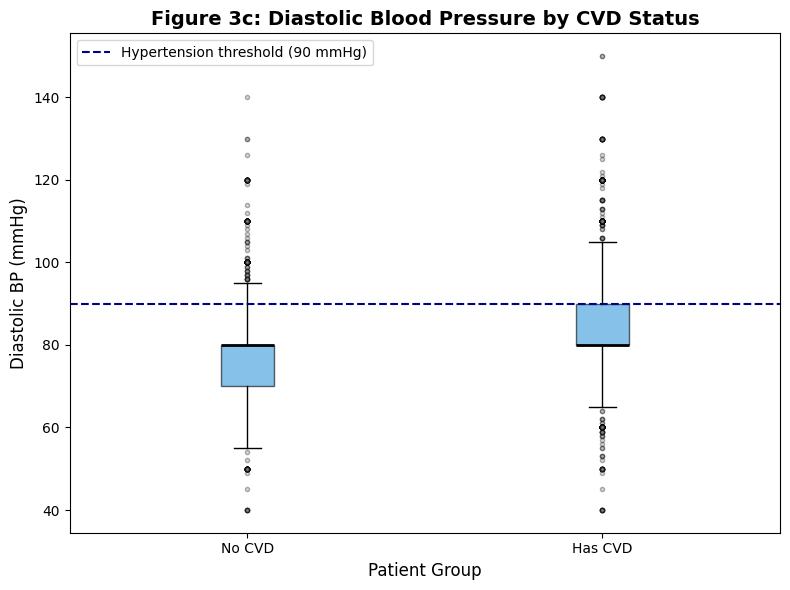

Chart 3c saved!


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot([no_cvd['ap_lo'], has_cvd['ap_lo']],
           labels=['No CVD', 'Has CVD'],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6),
           medianprops=dict(color='black', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='gray',
                          markersize=3, alpha=0.3))

ax.set_title('Figure 3c: Diastolic Blood Pressure by CVD Status',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Diastolic BP (mmHg)', fontsize=12)
ax.set_xlabel('Patient Group', fontsize=12)

# Reference line at 90 (diastolic hypertension threshold)
ax.axhline(y=90, color='darkblue', linestyle='--',
           linewidth=1.5, label='Hypertension threshold (90 mmHg)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart3c_diastolic_bp_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3c saved!")


Diastolic blood pressure analysis mirrors the systolic pattern, with CVD-positive patients showing a higher median (~80–85 mmHg) compared to CVD-negative patients (~75–80 mmHg), with the CVD group's IQR (80–90 mmHg) approaching the clinical diastolic hypertension threshold of 90 mmHg. However, comparing both BP box plots reveals that the inter-group separation is more pronounced in systolic pressure, suggesting systolic BP is the stronger discriminating factor between CVD and non-CVD patients a finding consistent with established cardiovascular literature

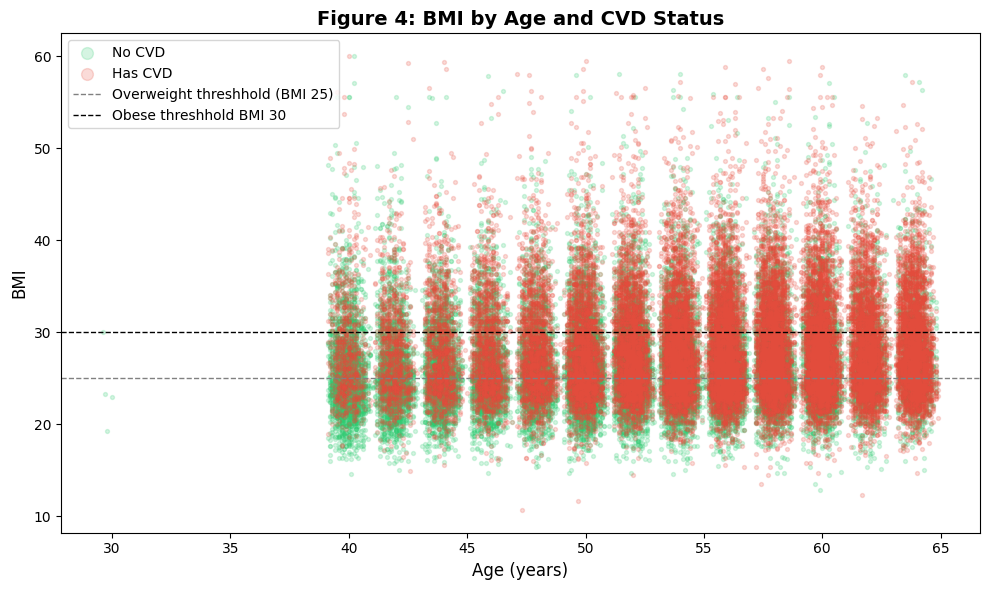

Chart 4 saved!


In [20]:
fig, ax =plt.subplots(figsize=(10,6))

ax.scatter(no_cvd['age'], no_cvd['bmi'],
           c= '#2ecc71', alpha=0.2, s=8,
           label='No CVD')

ax.scatter(has_cvd['age'], has_cvd['bmi'], c='#e74c3c',
           alpha=0.2, s=8, label='Has CVD')

# Refeerence lines
ax.axhline(y=25,
 color='gray',
 linestyle='--',
 linewidth=1,
 label='Overweight threshhold (BMI 25)')

ax.axhline(y=30,
 color='black',
 linestyle='--',
 linewidth=1,
 label='Obese threshhold BMI 30')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('BMI', fontsize=12)
ax.set_title('Figure 4: BMI by Age and CVD Status',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, markerscale=3)

plt.tight_layout()
plt.savefig('chart4_bmi_age_cvd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")


Most scatter plots lie above the 25 threshold for BMI indicating a large number of patients are overweight while a substantial number of patients are above the BMi= 30 threshhold indicating a large number of patients are obese

There are also outilers in the scatter plot with some points appearing below BMI 15 and others appearing above BMI 55-60

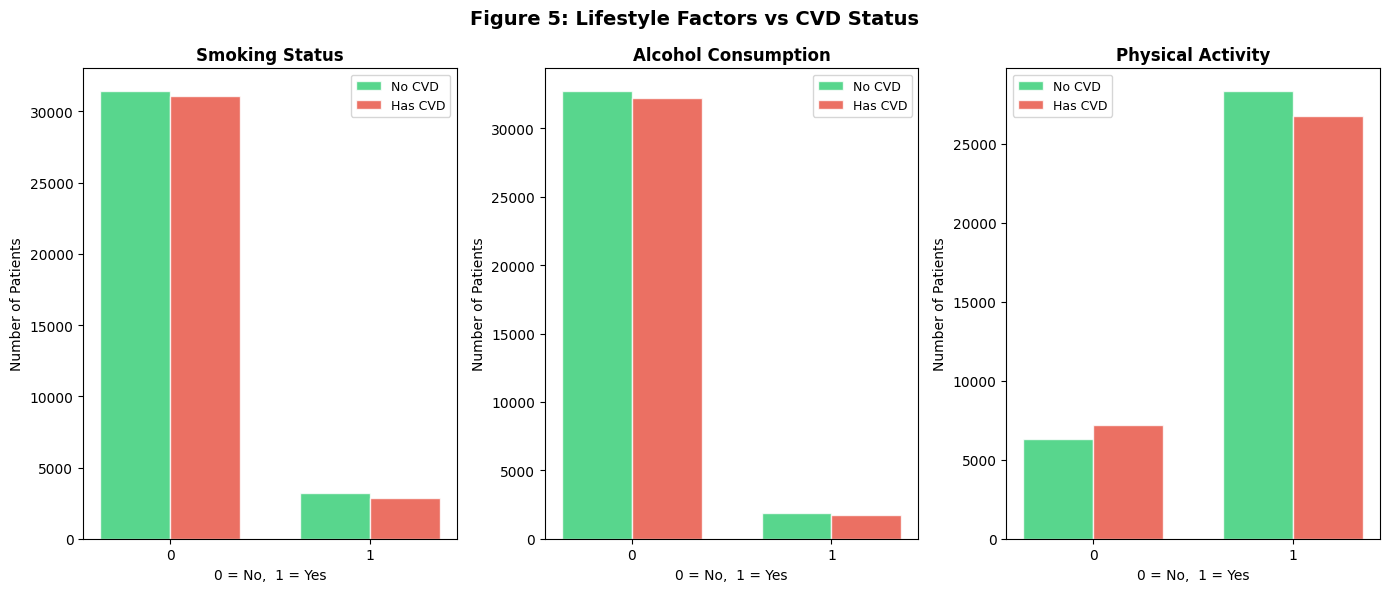

Chart 5 saved!


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

lifestyle = ['smoke', 'alco', 'active']
titles = ['Smoking Status', 'Alcohol Consumption', 'Physical Activity']
colors_no = '#2ecc71'
colors_yes = '#e74c3c'

for i, (feature, title) in enumerate(zip(lifestyle, titles)):
    # Count CVD vs No CVD for each lifestyle value
    counts = df.groupby([feature, 'cardio']).size().unstack()

    x = range(len(counts))
    width = 0.35

    axes[i].bar([p - width/2 for p in x], counts[0],
                width=width, label='No CVD',
                color=colors_no, alpha=0.8, edgecolor='white')
    axes[i].bar([p + width/2 for p in x], counts[1],
                width=width, label='Has CVD',
                color=colors_yes, alpha=0.8, edgecolor='white')

    axes[i].set_title(f'{title}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('0 = No,  1 = Yes', fontsize=10)
    axes[i].set_ylabel('Number of Patients', fontsize=10)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(counts.index)
    axes[i].legend(fontsize=9)

plt.suptitle('Figure 5: Lifestyle Factors vs CVD Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_lifestyle_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

Most of the patients are non-smokers and they dont drink but majority of them are involed in physical activity with CVD being slightly prevalent in those with no physical activity showing that physical activity is the biggest determinant of CVD  

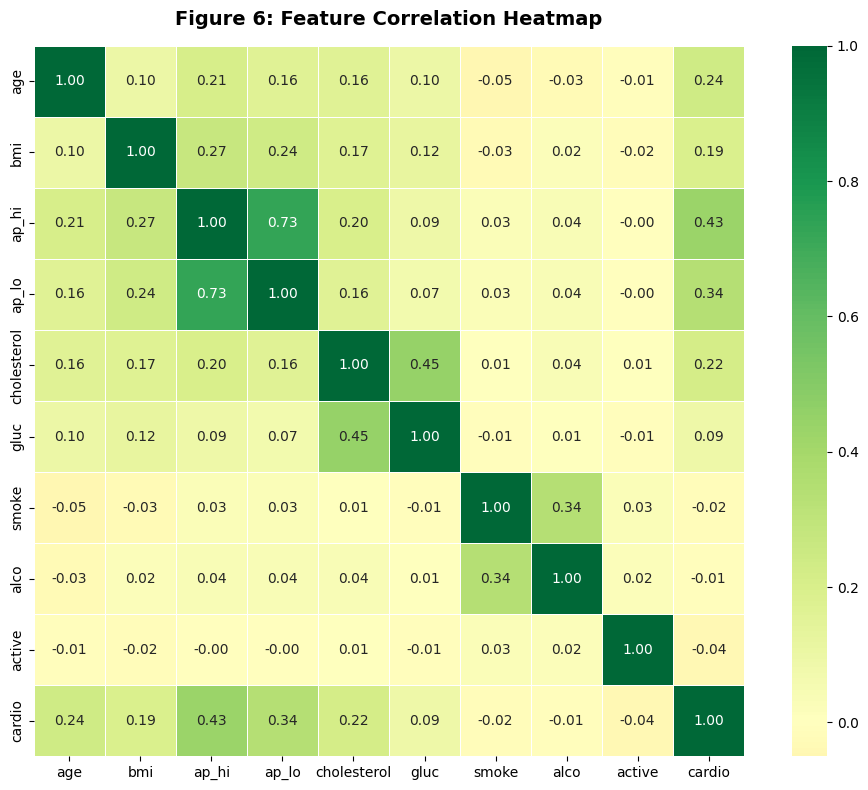

Chart 6 saved!


In [22]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))


cols = ['age', 'bmi', 'ap_hi', 'ap_lo',
        'cholesterol', 'gluc', 'smoke',
        'alco', 'active', 'cardio']

corr = df[cols].corr().round(2)

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Figure 6: Feature Correlation Heatmap',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

The correlation heatmap reveals that blood pressure variables show the strongest association with cardiovascular disease. Systolic blood pressure (r = 0.43) and diastolic blood pressure (r = 0.34) display the highest correlations with CVD status. Age, cholesterol, and BMI also show moderate positive relationships with cardiovascular disease. In contrast, lifestyle variables such as smoking, alcohol consumption, and physical activity exhibit very weak correlations with CVD in this dataset.

In [23]:
duplicates =df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of dataset: {(duplicates/len(df))*100:.2f}%")

Number of duplicate rows: 0
Percentage of dataset: 0.00%


There are no duplicate rows

In [24]:
#  class check balance
print("FInal class balance: ")
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True) * 100)

FInal class balance: 
cardio
0    34663
1    33937
Name: count, dtype: int64
cardio
0    50.529155
1    49.470845
Name: proportion, dtype: float64


In [25]:
print("FINAL CLEAN DATASET")
print(f"Rows: {len(df)}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn list:")
print(df.columns.tolist())
print(f"\nAny nulls remaining: {df.isnull().sum().sum()}")

FINAL CLEAN DATASET
Rows: 68600
Columns: 14

Column list:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']

Any nulls remaining: 0


In [26]:
df.to_csv('cardio_clean.csv', index=False)
print("Clean dataset saved as cardio_clean.csv ")

Clean dataset saved as cardio_clean.csv 


The analysis will use ID3 C4.5 Kmeans SVMs and APrior rule clustering

In [27]:
# Normalizing the features using minmax
from sklearn.preprocessing import MinMaxScaler

cluster_features = ['age', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'active']
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[cluster_features])

print("Original age range:", df['age'].min(), "-", df['age'].max())
print("Scaled age range: ",
      df_scaled[:, 0].min().round(2), "-",
      df_scaled[:, 0].max().round(2))
print("\nData ready for clustering")

Original age range: 29.6 - 64.9
Scaled age range:  0.0 - 1.0

Data ready for clustering


K=1 done, WCSS = 28721
K=2 done, WCSS = 17881
K=3 done, WCSS = 11281
K=4 done, WCSS = 8759
K=5 done, WCSS = 7531
K=6 done, WCSS = 6514
K=7 done, WCSS = 5497
K=8 done, WCSS = 4970
K=9 done, WCSS = 4429
K=10 done, WCSS = 4096


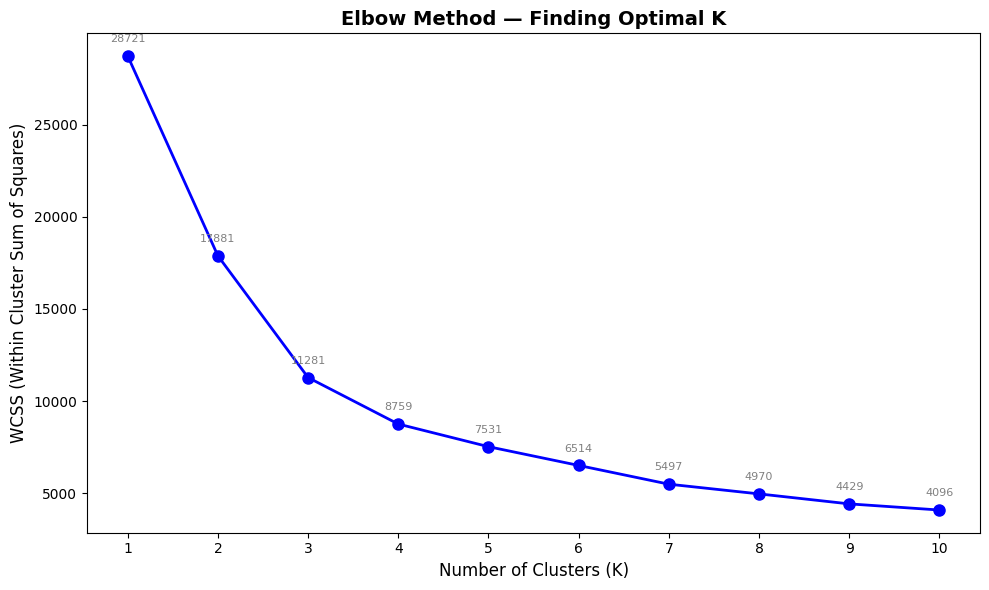

Elbow plot saved!


In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_range = range (1, 11)
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)
  print(f"K={k} done, WCSS = {kmeans.inertia_:.0f}")

  # Plot the elbow
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Within Cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method — Finding Optimal K',
             fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))

# Annotate each point with its WCSS value
for k, w in zip(k_range, wcss):
    ax.annotate(f'{w:.0f}', xy=(k, w),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Elbow plot saved!")

The WCSS drop off has diminishing returs at k=4 therefore k=4 is the WCSS elbow and is going to be the value for k

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)

print("Patients per cluster:")
print(df['cluster'].value_counts().sort_index())
print(f"\nTotal: {len(df)}")



Patients per cluster:
cluster
0    40087
1    12716
2     7196
3     8601
Name: count, dtype: int64

Total: 68600


clsuter 0 has a higher number of patients with 40,0847 patients which shows majority of patienst share similar characteristics

In [30]:
#mean of each feature per cluster
profile = df.groupby('cluster')[['age', 'bmi', 'ap_hi', 'ap_lo',
                                  'cholesterol', 'gluc',
                                  'active', 'cardio']].mean().round(2)

print(" CLUSTER PROFILES ")
print(profile)

 CLUSTER PROFILES 
           age    bmi   ap_hi  ap_lo  cholesterol  gluc  active  cardio
cluster                                                                
0        52.70  26.87  124.70  80.40         1.00  1.04    1.00    0.42
1        53.28  27.52  126.46  81.21         1.26  1.13    0.00    0.52
2        55.15  29.13  131.50  83.48         2.36  2.69    0.89    0.62
3        54.52  28.64  132.09  83.78         2.39  1.00    1.00    0.68


From the averages above cluster 0 can be labeled as low risk as they have the lowest CVD rate are fully active and have normal gluecose and cholesterol - cluster 0 should maintain their healthy habits.
cluster 1 are a sedentary risk group as they are least active and that has pushed their CVD occurence rate to 52% in comparisson to group 0 -cluster 1 should have excersise intervention programs
Group 2 are the metabollic risk group as they have elevated cholesterol and glucose levels which puts them at metabollic risk - cluster 3 shoud have dietary and metabolic screening programs
Group3 are at high clinical risk since they are the Highest BP, highest cholesterol, with the higest CVD rate despite being active - clustr 3 are in immediate need of cliinical intevention

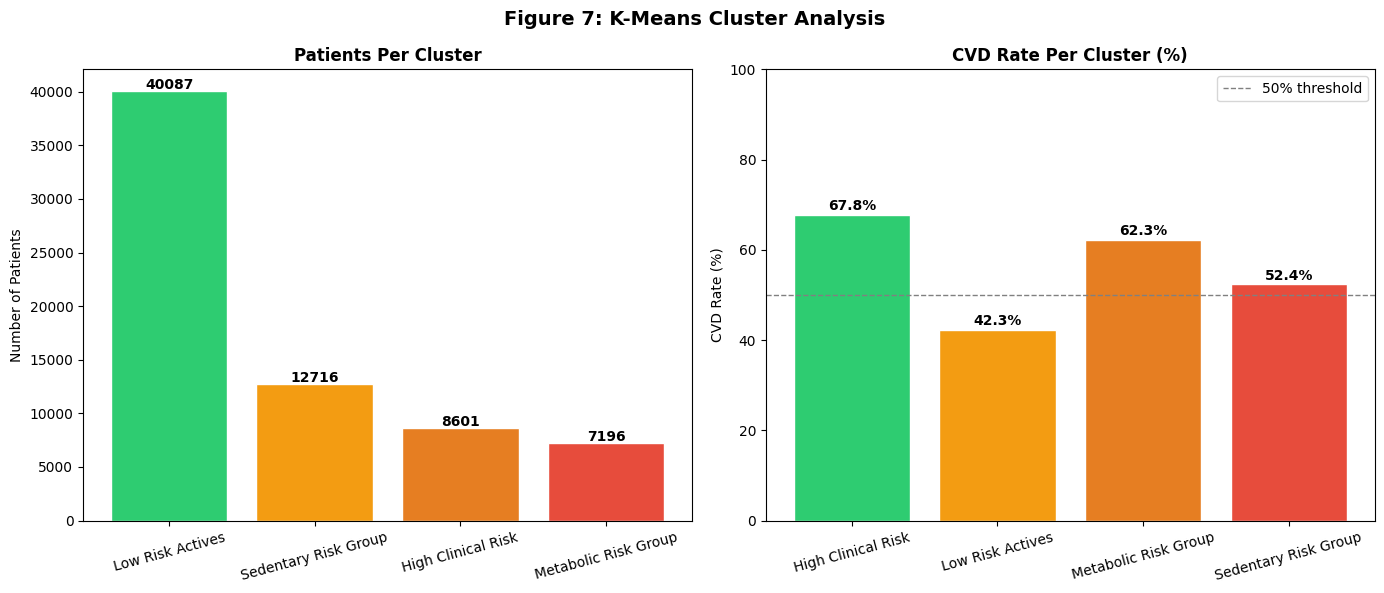

Chart 7 saved!


In [31]:
cluster_names = {
    0: 'Low Risk Actives',
    1: 'Sedentary Risk Group',
    2: 'Metabolic Risk Group',
    3: 'High Clinical Risk'
}
df['cluster_name'] = df['cluster'].map(cluster_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cluster sizes
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
counts = df['cluster_name'].value_counts()

axes[0].bar(counts.index, counts.values,
            color=colors, edgecolor='white')
axes[0].set_title('Patients Per Cluster',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Plot 2: CVD rate per cluster
cvd_rates = df.groupby('cluster_name')['cardio'].mean() * 100

axes[1].bar(cvd_rates.index, cvd_rates.values,
            color=colors, edgecolor='white')
axes[1].set_title('CVD Rate Per Cluster (%)',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('CVD Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=50, color='gray', linestyle='--',
                linewidth=1, label='50% threshold')
axes[1].legend()
for i, v in enumerate(cvd_rates.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Figure 7: K-Means Cluster Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")

Cluster size analysis reveals that the majority of patients (40,087) fall into the Low Risk Actives group, suggesting that most patients maintain reasonably healthy lifestyle habits. However, even this lowest-risk group carries a 42% CVD rate, indicating that cardiovascular risk is pervasive across the entire dataset. The Sedentary Risk Group and Metabolic Risk Group represent progressively higher risk, requiring targeted exercise and dietary interventions respectively. Most critically, the High Clinical Risk cluster  though the smallest active group carries the highest CVD probability at 67.8%, indicating that patients in this segment require immediate clinical intervention rather than lifestyle modification alone

In [32]:
from sklearn.model_selection import train_test_split

# x - features y- target
X = df[['age', 'bmi', 'ap_hi', 'ap_lo',
        'cholesterol', 'gluc', 'smoke',
        'alco', 'active']]
y = df['cardio']

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 54880
Testing samples: 13720


The data is split in 80% as the training data and 20% as the test data to evaluate the model's perfomance on new data

In [33]:
# ID3 decision tree

from sklearn.tree import DecisionTreeClassifier

id3_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

id3_tree.fit(X_train, y_train)
print("ID3 Decision Tree trained: ")
print(f"Tree depth: {id3_tree.get_depth()}")
print(f"Number of leaves: {id3_tree.get_n_leaves()}")

ID3 Decision Tree trained: 
Tree depth: 5
Number of leaves: 32


ID3 Accuracy: 72.96%

 Classification Report 
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.74      6932
     Has CVD       0.75      0.68      0.71      6788

    accuracy                           0.73     13720
   macro avg       0.73      0.73      0.73     13720
weighted avg       0.73      0.73      0.73     13720



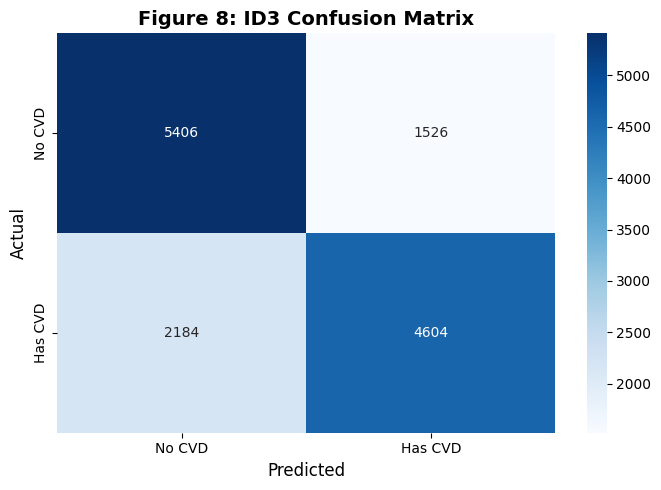

In [34]:
# Evaluate iD3 performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Make predictions on test data
y_pred_id3 = id3_tree.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_id3)
print(f"ID3 Accuracy: {accuracy*100:.2f}%")
print()

# Detailed report
print(" Classification Report ")
print(classification_report(y_test, y_pred_id3,
      target_names=['No CVD', 'Has CVD']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_id3)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CVD', 'Has CVD'],
            yticklabels=['No CVD', 'Has CVD'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Figure 8: ID3 Confusion Matrix',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_id3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

The ID3 Decision Tree achieved an overall accuracy of 72.96% on the test set. Precision for CVD detection was 75%, however recall for CVD-positive cases was only 68%, indicating that the model failed to detect approximately 32% of actual cardiovascular disease cases. In a clinical context this false negative rate represents a significant limitation, as undetected CVD cases could result in delayed treatment. The F1 scores of 0.74 and 0.71 for the two classes indicate reasonably balanced performance without significant class bias.

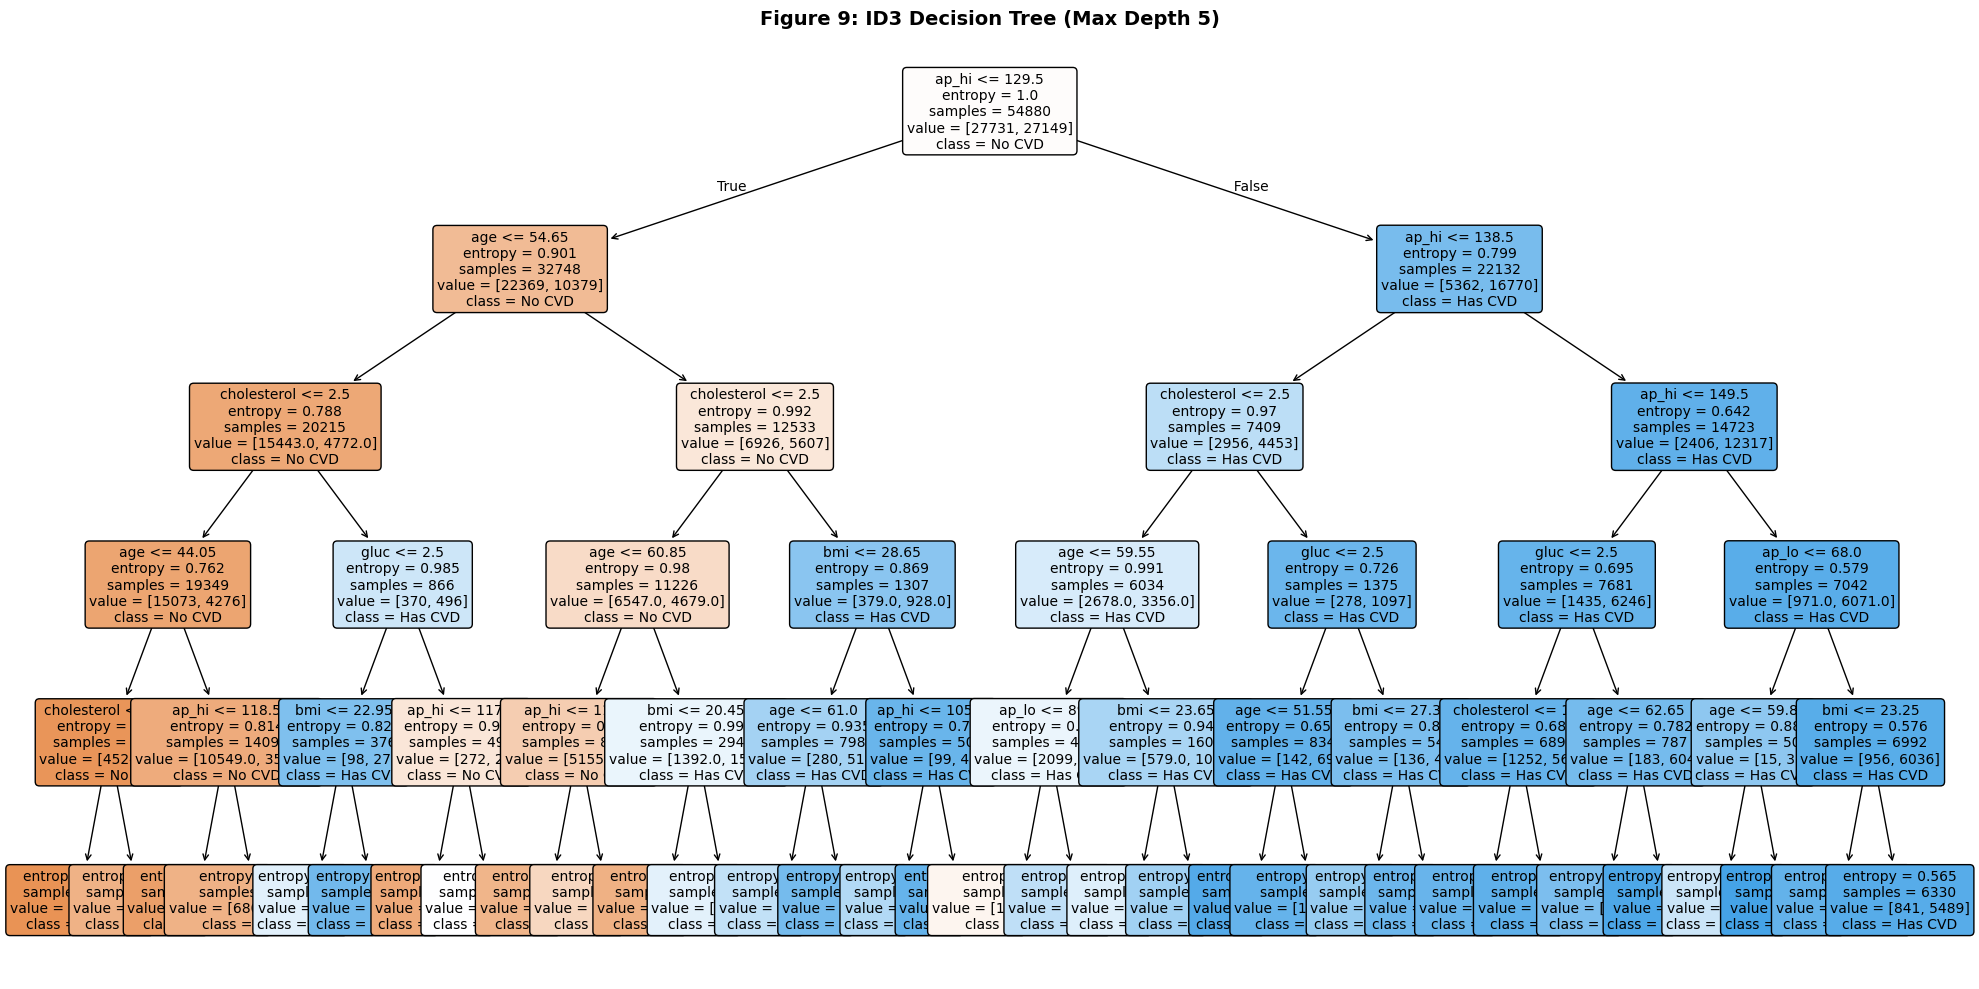

ID3 tree visualisation saved!


In [35]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(id3_tree,
          feature_names=X.columns.tolist(),
          class_names=['No CVD', 'Has CVD'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)

ax.set_title('Figure 9: ID3 Decision Tree (Max Depth 5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart9_id3_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("ID3 tree visualisation saved!")

The root node of the ID3 Decision Tree split on systolic blood pressure (ap_hi ≤ 129.5), identifying it as the single most informative feature for CVD classification. This finding independently corroborates the correlation analysis which assigned ap_hi the highest correlation coefficient (r = 0.43) with CVD status, reinforcing systolic hypertension as the dominant cardiovascular risk factor in this dataset

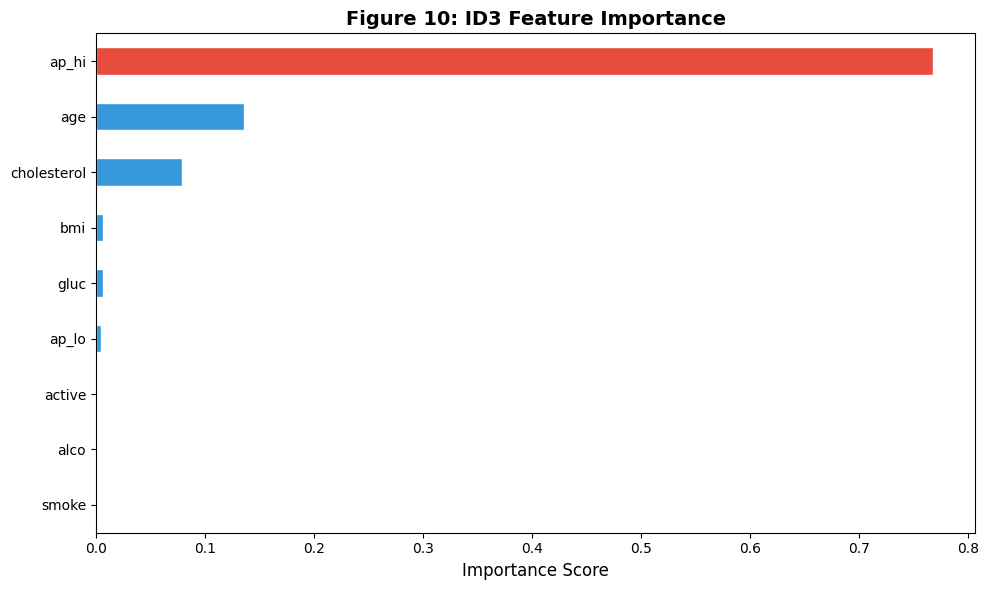

Feature importance chart saved!


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

importances = pd.Series(id3_tree.feature_importances_,
                        index=X.columns)
importances = importances.sort_values(ascending=True)

colors = ['#e74c3c' if i == importances.index[-1]
          else '#3498db' for i in importances.index]

importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Figure 10: ID3 Feature Importance',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('chart10_id3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved!")

Feature importance analysis of the ID3 Decision Tree revealed systolic blood pressure (ap_hi) as the dominant predictive feature, followed by age and cholesterol level. This ranking is consistent across multiple analytical techniques applied in this study  including correlation analysis, box plot comparison and cluster profiling suggesting that these three features form the core risk triad for cardiovascular disease prediction in this dataset.

In [ ]:
# c4.5 decision tree
c45_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

c45_tree.fit(X_train, y_train)
print("C4.5 Decision Tree trained!")
print(f"Tree depth: {c45_tree.get_depth()}")
print(f"Number of leaves: {c45_tree.get_n_leaves()}")

C4.5 Accuracy: 72.94%

Classification Report
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.74      6932
     Has CVD       0.75      0.68      0.71      6788

    accuracy                           0.73     13720
   macro avg       0.73      0.73      0.73     13720
weighted avg       0.73      0.73      0.73     13720



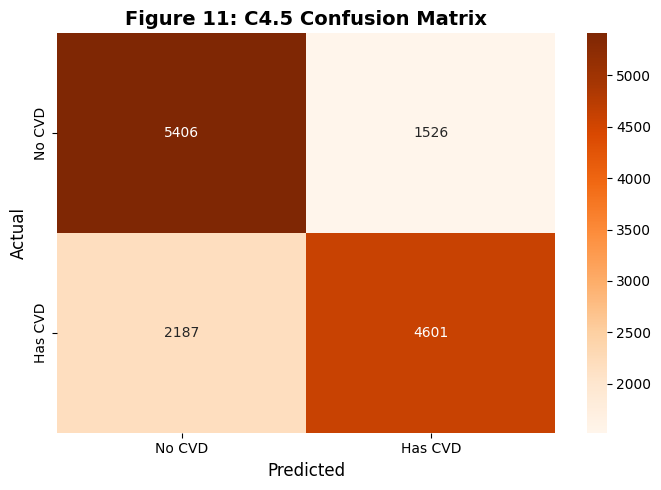

C4.5 confusion matrix saved!


In [38]:
# Make predictions
y_pred_c45 = c45_tree.predict(X_test)

# Accuracy
accuracy_c45 = accuracy_score(y_test, y_pred_c45)
print(f"C4.5 Accuracy: {accuracy_c45*100:.2f}%")
print()

# Detailed report
print("Classification Report")
print(classification_report(y_test, y_pred_c45,
      target_names=['No CVD', 'Has CVD']))

# Confusion Matrix
cm_c45 = confusion_matrix(y_test, y_pred_c45)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_c45, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No CVD', 'Has CVD'],
            yticklabels=['No CVD', 'Has CVD'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Figure 11: C4.5 Confusion Matrix',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart11_c45_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("C4.5 confusion matrix saved!")

In [39]:
print(" C4.5 Full Metrics ")
print(classification_report(y_test, y_pred_c45,
      target_names=['No CVD', 'Has CVD']))

 C4.5 Full Metrics 
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.74      6932
     Has CVD       0.75      0.68      0.71      6788

    accuracy                           0.73     13720
   macro avg       0.73      0.73      0.73     13720
weighted avg       0.73      0.73      0.73     13720



There's a 0.02 differential in accuracy between ID3 and C4.5 for the prediction task and identical precision(0.75) recall(0.68) and F1-score of(.71) for CVD detection

In [40]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# scaled data
X_scaled = pd.DataFrame(df_scaled, columns=cluster_features)
y_knn = df['cardio'].reset_index(drop=True)

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_scaled, y_knn, test_size=0.2, random_state=42)

# Test K values from 1 to 20
k_scores = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_knn)
    score = accuracy_score(y_test_knn, knn.predict(X_test_knn))
    k_scores.append(score)
    print(f"K={k:2d} | Accuracy: {score*100:.2f}%")

K= 1 | Accuracy: 63.75%
K= 2 | Accuracy: 64.53%
K= 3 | Accuracy: 67.81%
K= 4 | Accuracy: 67.94%
K= 5 | Accuracy: 69.28%
K= 6 | Accuracy: 69.72%
K= 7 | Accuracy: 69.98%
K= 8 | Accuracy: 70.47%
K= 9 | Accuracy: 70.58%
K=10 | Accuracy: 71.11%
K=11 | Accuracy: 71.17%
K=12 | Accuracy: 71.50%
K=13 | Accuracy: 71.71%
K=14 | Accuracy: 71.73%
K=15 | Accuracy: 71.81%
K=16 | Accuracy: 72.05%
K=17 | Accuracy: 72.06%
K=18 | Accuracy: 71.92%
K=19 | Accuracy: 71.96%
K=20 | Accuracy: 72.14%


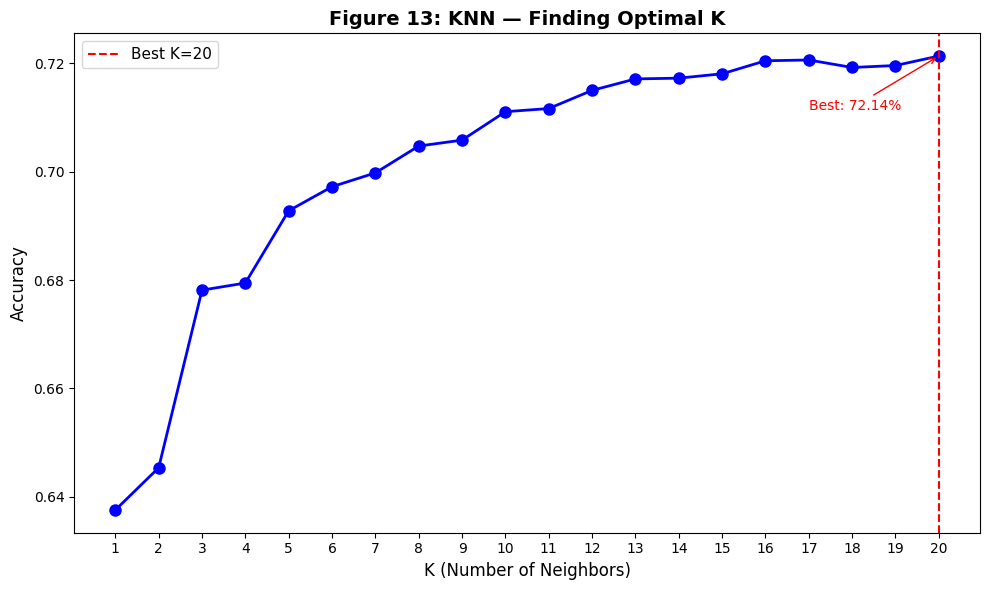

KNN optimal K chart saved!


In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(list(k_range), k_scores, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Figure 13: KNN — Finding Optimal K',
             fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))

# Highlight best K
best_k = k_scores.index(max(k_scores)) + 1
ax.axvline(x=best_k, color='red', linestyle='--',
           linewidth=1.5, label=f'Best K={best_k}')
ax.legend(fontsize=11)

# Annotate best point
ax.annotate(f'Best: {max(k_scores)*100:.2f}%',
            xy=(best_k, max(k_scores)),
            xytext=(best_k - 3, max(k_scores) - 0.01),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('chart13_knn_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()
print("KNN optimal K chart saved!")

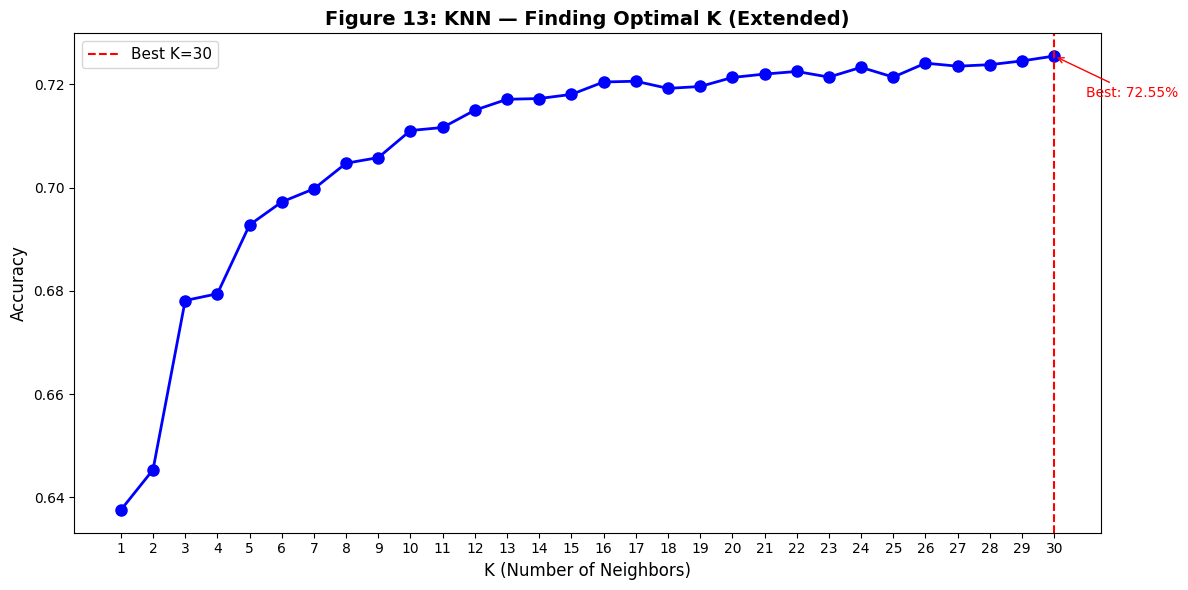


Best K: 30
Best Accuracy: 72.55%


In [42]:
k_scores_extended = []
k_range_extended = range(1, 31)

for k in k_range_extended:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_knn)
    score = accuracy_score(y_test_knn, knn.predict(X_test_knn))
    k_scores_extended.append(score)

# Plot extended range
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(k_range_extended), k_scores_extended,
        'bo-', linewidth=2, markersize=8)

best_k = k_scores_extended.index(max(k_scores_extended)) + 1
best_score = max(k_scores_extended)

ax.axvline(x=best_k, color='red', linestyle='--',
           linewidth=1.5, label=f'Best K={best_k}')
ax.annotate(f'Best: {best_score*100:.2f}%',
            xy=(best_k, best_score),
            xytext=(best_k + 1, best_score - 0.008),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Figure 13: KNN — Finding Optimal K (Extended)',
             fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range_extended))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart13_knn_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest K: {best_k}")
print(f"Best Accuracy: {best_score*100:.2f}%")

KNN Accuracy (K=30): 72.55%

 Classification Report 
              precision    recall  f1-score   support

      No CVD       0.71      0.77      0.74      6932
     Has CVD       0.74      0.68      0.71      6788

    accuracy                           0.73     13720
   macro avg       0.73      0.73      0.72     13720
weighted avg       0.73      0.73      0.72     13720



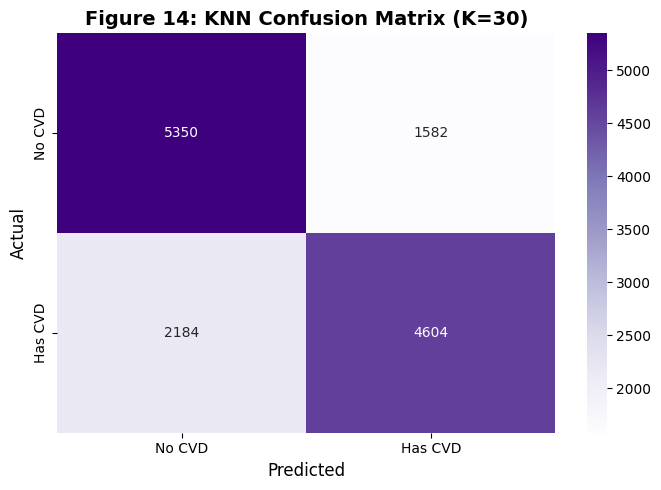

KNN confusion matrix saved!


In [43]:
# Final KNN with optimal K
knn_final = KNeighborsClassifier(n_neighbors=30)
knn_final.fit(X_train_knn, y_train_knn)
y_pred_knn = knn_final.predict(X_test_knn)

# Evaluate
print(f"KNN Accuracy (K=30): {accuracy_score(y_test_knn, y_pred_knn)*100:.2f}%")
print()
print(" Classification Report ")
print(classification_report(y_test_knn, y_pred_knn,
      target_names=['No CVD', 'Has CVD']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No CVD', 'Has CVD'],
            yticklabels=['No CVD', 'Has CVD'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Figure 14: KNN Confusion Matrix (K=30)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart14_knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("KNN confusion matrix saved!")

KNN, ID3 and C4.5 all achieved comparable accuracy between 72.55% and 72.96%, with identical CVD recall of 0.68 across all three models. This convergence suggests a performance ceiling inherent to the dataset rather than a limitation of any individual algorithm


In [44]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    probability=True
)

svm_model.fit(X_train_knn, y_train_knn)
print("SVM Model trained!")

SVM Model trained!


SVM Accuracy: 73.07%

 Classification Report 
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.75      6932
     Has CVD       0.75      0.68      0.71      6788

    accuracy                           0.73     13720
   macro avg       0.73      0.73      0.73     13720
weighted avg       0.73      0.73      0.73     13720



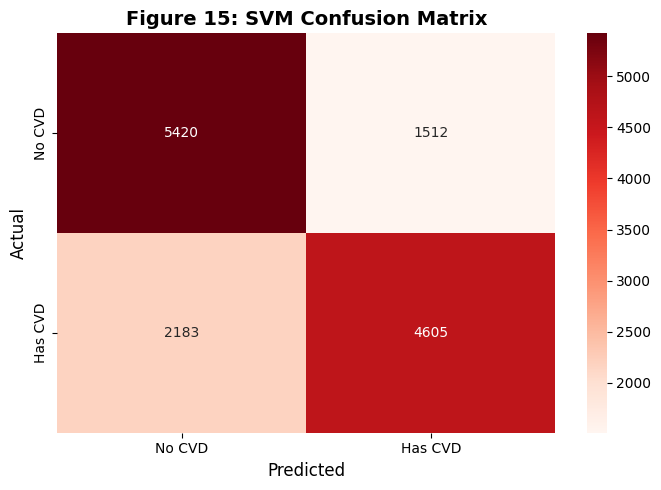

SVM confusion matrix saved!


In [45]:
# Make predictions
y_pred_svm = svm_model.predict(X_test_knn)

# Accuracy
print(f"SVM Accuracy: {accuracy_score(y_test_knn, y_pred_svm)*100:.2f}%")
print()

# Detailed report
print(" Classification Report ")
print(classification_report(y_test_knn, y_pred_svm,
      target_names=['No CVD', 'Has CVD']))

# Confusion Matrix
cm_svm = confusion_matrix(y_test_knn, y_pred_svm)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No CVD', 'Has CVD'],
            yticklabels=['No CVD', 'Has CVD'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Figure 15: SVM Confusion Matrix',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart15_svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("SVM confusion matrix saved!")

Across all four classification models, performance metrics were remarkably consistent. Precision for CVD detection held at 0.75, recall at 0.68, and F1 score at 0.71 regardless of algorithm. SVM achieved the marginally highest accuracy at 73.07%, followed closely by ID3 (72.96%), C4.5 (72.94%) and KNN (72.55%). The uniformity of results across fundamentally different algorithms  a distance-based classifier, two decision tree variants, and a maximum margin classifier  strongly suggests that the performance ceiling is imposed by the dataset's feature limitations rather than algorithmic constraints.

Since apriori works with categorical values we have to transform the continous data into categories


In [51]:
# Apriori Association Rule Mining
df_apriori = df.copy()

# Binning the age into groups
df_apriori['age_group'] = pd.cut(df['age'],
                                 bins=[0, 40, 50, 60, 100],
                                 labels = ['Young', 'Middle-aged', 'Senior', 'Elderly']

                                 )

# Binning BMI categories
df_apriori['bmi_cat'] = pd.cut(df['bmi'],
                                     bins=[0,18.5,25,30,100],
                                     labels=['Underweight', 'Normal', 'Overweight', 'Obese']

                                     )
# Blood pressure categories
df_apriori['bp_cat'] = pd.cut(df['ap_hi'],
                              bins=[0,120,129,139,300],
                              labels=['Normal', 'Elevated', 'High Stage 1', 'High Stage 2']


)

# Cholesterol labels
df_apriori['chol_cat']= df['cholesterol'].map({1: 'Normal', 2: 'Above Normal', 3: 'High Cholesterol'})

# Gluecose categories
df_apriori['gluc_cat'] = df['gluc'].map({
    1: 'Normal',
    2: 'Above Normal',
    3: 'High Glucose'
})

# Lifestyle labels
df_apriori['smoke_cat'] = df['smoke'].map({
    0: 'Non-Smoker', 1: 'Smoker'})
df_apriori['alco_cat'] = df['alco'].map({
    0: 'Non-Alcoholic', 1: 'Drinks alchohol'})
df_apriori['active_cat'] = df['active'].map({
    0: 'Inactive', 1: 'Active'})

# CVD Labels
df_apriori['cardio_cat'] = df['cardio'].map({
    0: 'No CVD',  1: 'Has CVD'
})

print("Categories created!")
print(df_apriori[['age_group', 'bmi_cat', 'bp_cat', 'chol_cat', 'cardio_cat']]
      .head(10))

Categories created!
     age_group     bmi_cat        bp_cat          chol_cat cardio_cat
0       Senior      Normal        Normal            Normal     No CVD
1       Senior       Obese  High Stage 2  High Cholesterol    Has CVD
2       Senior      Normal  High Stage 1  High Cholesterol    Has CVD
3  Middle-aged  Overweight  High Stage 2            Normal    Has CVD
4  Middle-aged      Normal        Normal            Normal     No CVD
5       Senior  Overweight        Normal      Above Normal     No CVD
6      Elderly       Obese  High Stage 1  High Cholesterol     No CVD
7      Elderly  Overweight  High Stage 1  High Cholesterol    Has CVD
8  Middle-aged  Overweight        Normal            Normal     No CVD
9       Senior  Overweight        Normal            Normal     No CVD


Installing mixtend - the library which contains apriori

In [54]:
!pip install mlxtend --quiet
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

apriori_cols = [
    'age_group',
    'bmi_cat',
    'bp_cat',
    'chol_cat',
    'gluc_cat',
    'smoke_cat',
    'alco_cat',
    'active_cat',
    'cardio_cat'
]

# Drop NaN rows
df_apriori_clean = df_apriori[
    apriori_cols
].dropna()
print(f"Rows ready for Apriori: {len(df_apriori_clean)}")

# Convert each row into a list of items (like a shopping basket)
transactions = df_apriori_clean.apply(
    lambda row: list(row.values), axis=1).tolist()

print("\nExample transaction (patient 1):")
print(transactions[0])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rows ready for Apriori: 68600


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Example transaction (patient 1):
['Senior', 'Normal', 'Normal', 'Normal', 'Normal', 'Non-Smoker', 'Non-Alcoholic', 'Active', 'No CVD']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Each patientis now a basket of 9 items
For Example patient one can be read as Patient 1 is a senior with a normal BMI, normal BP, normal cholesterol, normal glucose, and  is a non smoker, and a non alcoholic whose active and has no CVD therefore a perfectly healthy profile

In [55]:
# Encoding transactions into a format apriori understands
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
print (f"Encoded shape: {df_encoded.shape}")
print("Sample of encoded data:")
print(df_encoded.iloc[:3, :5])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Encoded shape: (68600, 22)
Sample of encoded data:
   Above Normal  Active  Drinks alchohol  Elderly  Elevated
0         False    True            False    False     False
1         False    True            False    False     False
2         False   False            False    False     False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [58]:
# Frequent itemsets
frequent_itemsets = apriori(df_encoded,
                            min_support=0.10,
                            use_colnames=True)

frequent_itemsets['legnth'] = frequent_itemsets['itemsets'].apply(len)


print(f"Total frequent itemsets: {len(frequent_itemsets)}")
print("\nTop 10 most frequent itemsets: ")
print(frequent_itemsets.sort_values('support',
                                    ascending=False).head(10))


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Total frequent itemsets: 351

Top 10 most frequent itemsets: 
      support                             itemsets  legnth
12   0.952536                             (Normal)       1
10   0.946662                      (Non-Alcoholic)       1
11   0.912026                         (Non-Smoker)       1
70   0.902886              (Normal, Non-Alcoholic)       2
69   0.885029          (Non-Smoker, Non-Alcoholic)       2
74   0.868703                 (Normal, Non-Smoker)       2
179  0.844155  (Normal, Non-Smoker, Non-Alcoholic)       3
1    0.803324                             (Active)       1
29   0.765131                     (Normal, Active)       2
27   0.758294              (Non-Alcoholic, Active)       2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

90% of the 68,600 patients are both normal and non-alcoholic simultaneously
and
86% of patients are both normal and non-smokers while 88% are non-smokers who are non-alcoholic
and 84% of all patients have normal readings are non-smokers and dont drink
PS. These are trivial rules (technically correct but clinicallly useless) since majority of the patients fall into them makes them the dominant categories

In [59]:
# Generate association rues with confidence to filter the interesting ones
rules = association_rules(frequent_itemsets,
                          metric='confidence',
                          min_threshold=0.60) #dignifies a 60% confidence minimum

# Filter for rules where outcome is CVD related
cvd_rules = rules[
    rules['consequents'].astype(str).str.contains('CVD')
]

cvd_rules = cvd_rules.sort_values('lift', ascending=False)

print(f"Total rules generated: {len(rules)}")
print(f"Total CVD related rules: {len(cvd_rules)}")
print("\nTop 10 CVD association rules:")
print(cvd_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total rules generated: 1408
Total CVD related rules: 142

Top 10 CVD association rules:
                                            antecedents                       consequents   support  confidence      lift
1304                 (Non-Smoker, Normal, High Stage 2)  (Has CVD, Non-Alcoholic, Active)  0.138834    0.652776  1.769418
902                          (High Stage 2, Non-Smoker)  (Has CVD, Non-Alcoholic, Active)  0.157274    0.648144  1.756862
1303              (High Stage 2, Normal, Non-Alcoholic)     (Non-Smoker, Has CVD, Active)  0.138834    0.625797  1.754522
901                       (High Stage 2, Non-Alcoholic)     (Non-Smoker, Has CVD, Active)  0.157274    0.624002  1.749492
404                              (High Stage 2, Normal)                 (Has CVD, Active)  0.160015    0.677760  1.738106
909               (High Stage 2, Normal, Non-Alcoholic)                 (Has CVD, Active)  0.150087    0.676523  1.734933
922                  (Non-Smoker, Normal, High Stage 2)   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Every single top rule is anchored by High Stage 2 BP antecedent affirming the fact that hypertension is the dominant CVD dataset in the dataset, the consequents also highlights that active patients also develop CVD when their systolic BP is severely
elevated. Association rule mining revealed that a High stage 2 systolic BP >= 139 mmHg featured as the antecedent in all the top 10 CVD related rules eith confidences ranging from 0.648 to 0.678 and lift values ranging from 1.728 and 1.769. This finding reinfroces that clinical blood pressuure management is irreplacable and cannot be substituted by lifestyole modification alone